In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
# Step 1: Load Titanic dataset

df = sns.load_dataset('titanic')

print(df.shape)
print(df.head())

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
# Step 2: Quantify missing values

missing_counts = df.isnull().sum()

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent.round(2)
}).sort_values(
    by='missing_percent',
    ascending=False
)

print(
    missing_summary[
        missing_summary['missing_count'] > 0
    ]
)

             missing_count  missing_percent
deck                   688            77.22
age                    177            19.87
embarked                 2             0.22
embark_town              2             0.22


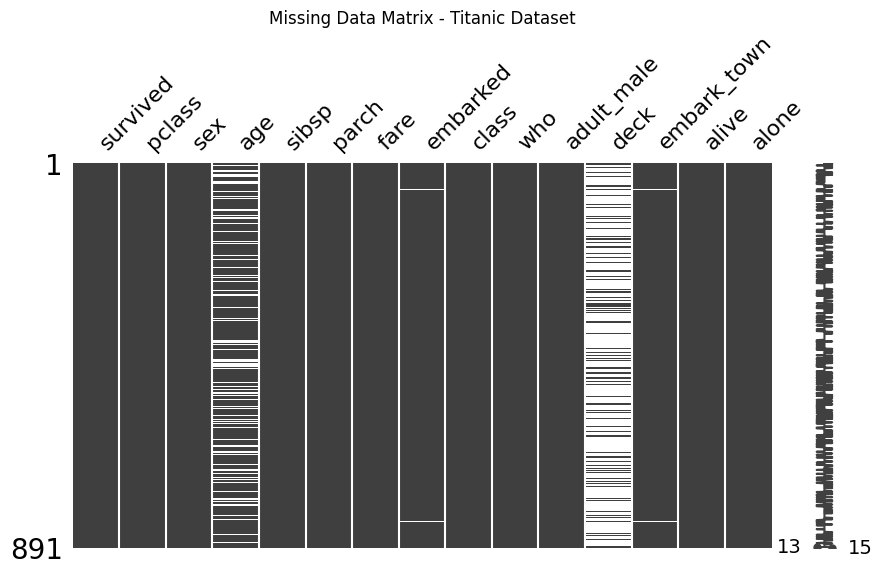

In [4]:
# Step 3: Missing data matrix

msno.matrix(
    df,
    figsize=(10, 5)
)

plt.title(
    'Missing Data Matrix - Titanic Dataset'
)

plt.show()


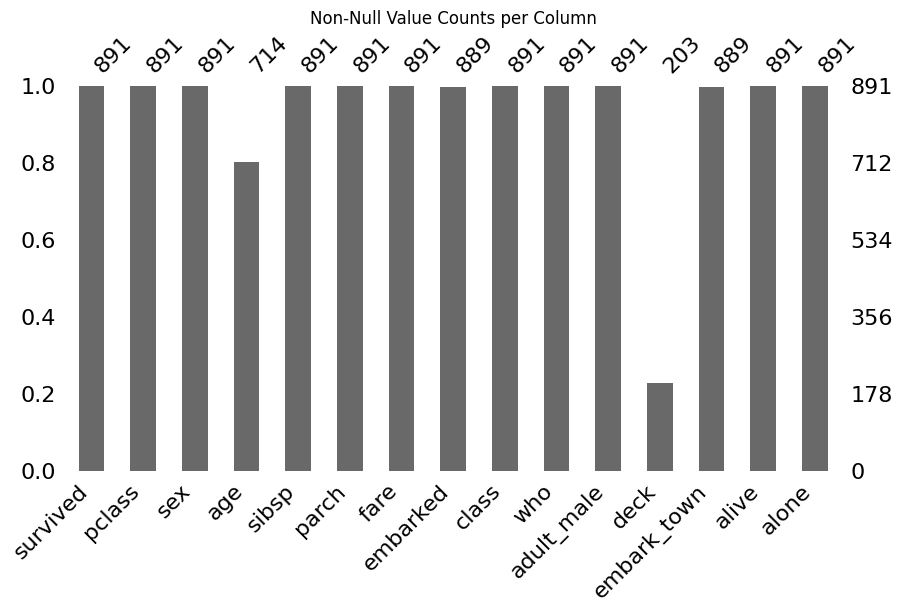

In [5]:
# Step 4: Bar chart

msno.bar(
    df,
    figsize=(10, 5)
)

plt.title(
    'Non-Null Value Counts per Column'
)

plt.show()


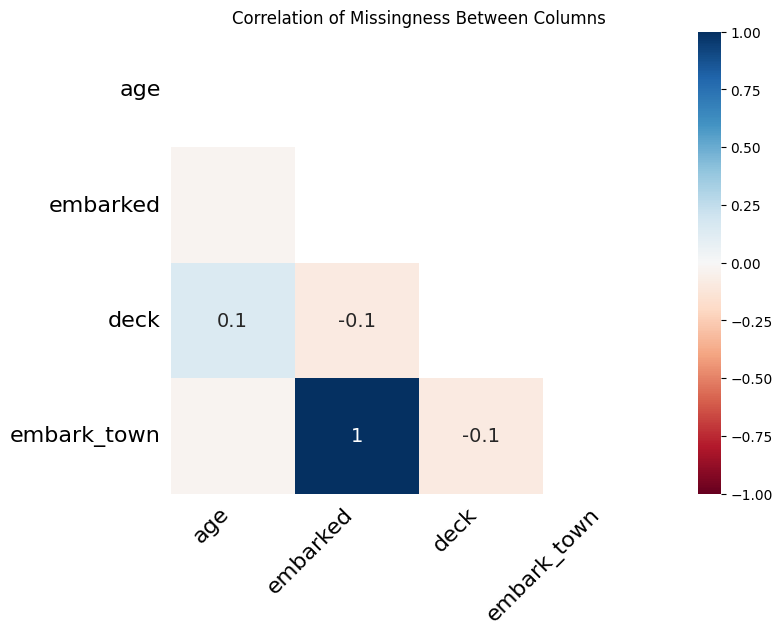

In [6]:
# Step 5: Missingness heatmap

msno.heatmap(
    df,
    figsize=(8, 6)
)

plt.title(
    'Correlation of Missingness Between Columns'
)

plt.show()


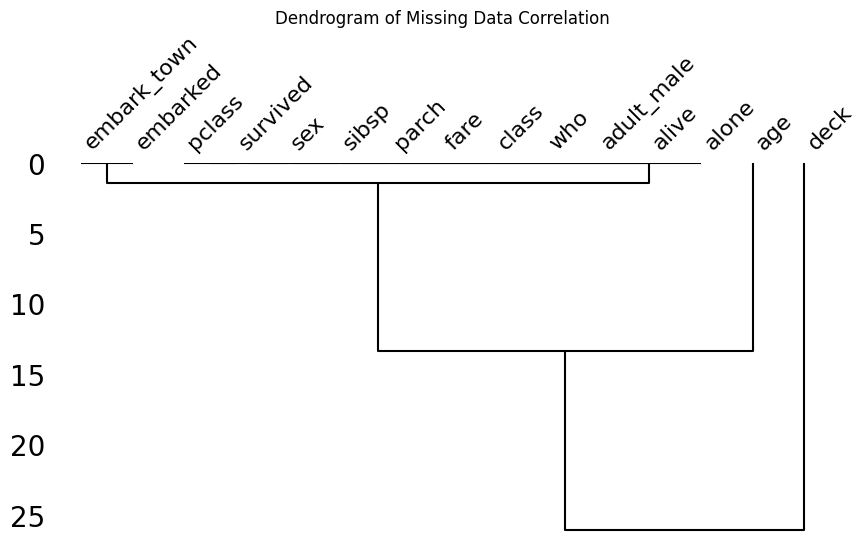

In [7]:
# Step 6: Dendrogram

msno.dendrogram(
    df,
    figsize=(10, 5)
)

plt.title(
    'Dendrogram of Missing Data Correlation'
)

plt.show()

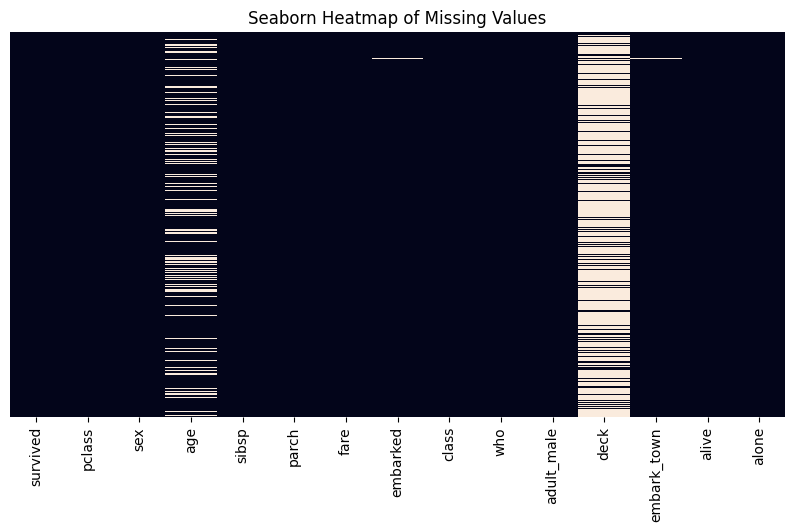

In [8]:
# Step 7: Seaborn heatmap

plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title(
    'Seaborn Heatmap of Missing Values'
)

plt.show()

In [9]:
# Step 8: Check MAR pattern

df['age_missing'] = (
    df['age'].isnull().astype(int)
)

cross_tab = pd.crosstab(
    df['pclass'],
    df['age_missing']
)

print(cross_tab)

chi2, p_value, dof, expected = (
    chi2_contingency(cross_tab)
)

print(
    f'Chi-square statistic: {chi2:.3f}, '
    f'p-value: {p_value:.5f}'
)

if p_value < 0.05:
    print(
        'Missingness in age is significantly '
        'related to pclass -> likely MAR'
    )
else:
    print(
        'No significant relationship found '
        '-> possibly MCAR'
    )

age_missing    0    1
pclass               
1            186   30
2            173   11
3            355  136
Chi-square statistic: 46.063, p-value: 0.00000
Missingness in age is significantly related to pclass -> likely MAR
